# Семинар 3. Акустическая диагностика подшипника — Python

От четырёх 12-секундных записей пройдём путь до модели: окна сигнала → 54 признака →
synthetic signal mixtures (синтетические смеси сигналов) → три модели случайного леса → проверка.

**Оговорка:** целевые значения 0–100 здесь задаются mixing coefficient (коэффициентом смешивания) сигналов.
Это *заданная шкала доли добавленного дефектного сигнала*, а не измеренный процент
физического износа реального оборудования. Для реальной диагностики нужна проверка на других
подшипниках и калибровка по измерениям состояния.

Запускайте ячейки сверху вниз. Данные лежат в `data_seminar/Bearing.mat`.

## Библиотеки и пути

NumPy и SciPy работают с сигналом; scikit-learn обучает модели и считает ошибки.
Все выходные файлы записываются в `output`, исходный MAT-файл не меняется.

![Путь от акустического сигнала к моделям](visualizations/01_от_сигнала_к_модели.png)

Одна запись превращается в много окон; каждое окно — в строку числовых признаков.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import loadmat, wavfile
from scipy.signal import hilbert
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import joblib

DATA = Path("data_seminar")
OUT = Path("output")
OUT.mkdir(exist_ok=True)
FS = 10_000
SEGMENT_LEN = 4_000
OVERLAP = 0.75
LABELS = {"normal": "Норма", "inner": "Внутреннее кольцо",
          "outer": "Внешнее кольцо", "roller": "Ролик"}
TARGET_NAMES = ["Внутреннее кольцо", "Внешнее кольцо", "Ролик"]
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

## Исходные записи

`loadmat` возвращает словарь. Каждая запись из MAT имеет форму `1 × 120000`;
`.ravel()` превращает её в одномерный сигнал. 120 000 отсчётов при 10 кГц — это 12 секунд.

In [2]:
raw = loadmat(DATA / "Bearing.mat")
signals = {key: raw[key].ravel().astype(float) for key in LABELS}
for key, signal in signals.items():
    print(f"{LABELS[key]:20s}: {len(signal):6d} отсчётов, "
          f"{len(signal) / FS:.1f} с, RMS = {np.sqrt(np.mean((signal - signal.mean())**2)):.4f}")
assert all(len(x) == 120_000 for x in signals.values())

Норма               : 120000 отсчётов, 12.0 с, RMS = 0.0727
Внутреннее кольцо   : 120000 отсчётов, 12.0 с, RMS = 0.2911
Внешнее кольцо      : 120000 отсчётов, 12.0 с, RMS = 0.6689
Ролик               : 120000 отсчётов, 12.0 с, RMS = 0.1385


## Послушаем и посмотрим

Для сравнения на графике сохраняем **общий масштаб оси Y**. В аудиоплеере нормируем
каждую запись отдельно ради слышимости, поэтому громкость плеера не годится для
количественного сравнения амплитуд.

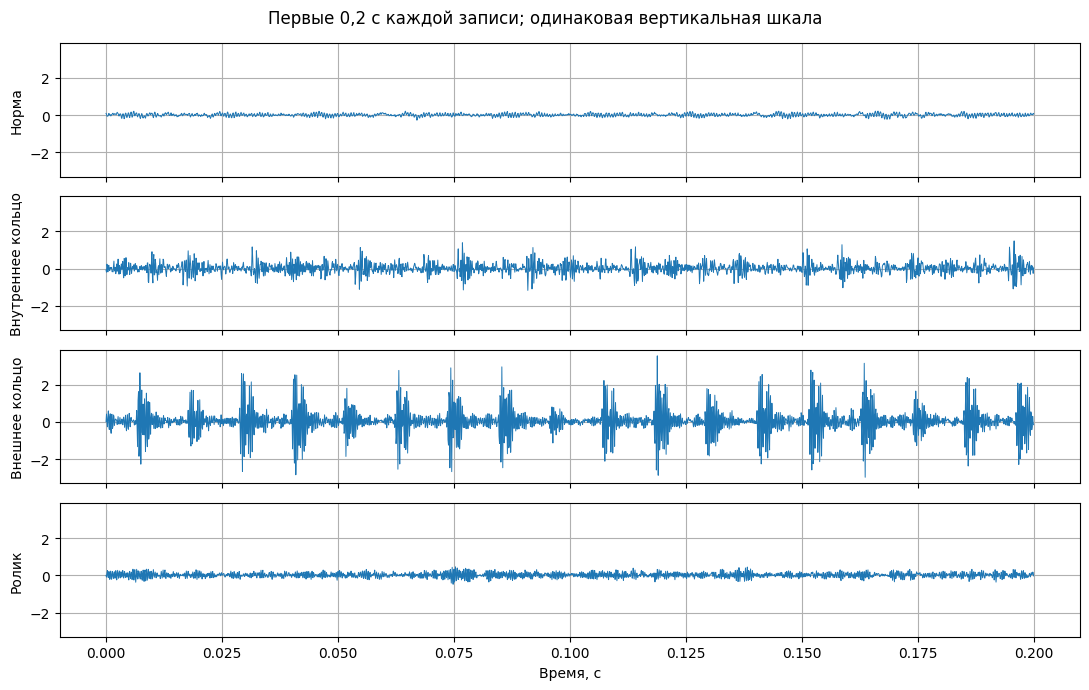

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 7), sharex=True, sharey=True)
t = np.arange(2_000) / FS
for ax, (key, signal) in zip(axes, signals.items()):
    ax.plot(t, signal[:2_000], lw=0.7)
    ax.set_ylabel(LABELS[key])
axes[-1].set_xlabel("Время, с")
fig.suptitle("Первые 0,2 с каждой записи; одинаковая вертикальная шкала")
plt.tight_layout()
plt.show()

In [4]:
for key in ["normal", "roller"]:
    x = signals[key]
    print(LABELS[key])
    display(Audio(x / np.max(np.abs(x)), rate=FS))

Норма


Ролик


## Режем сигнал на перекрывающиеся окна

Окно из 4000 отсчётов длится 0,4 с. При перекрытии 75% шаг равен 1000 отсчётам,
то есть 0,1 с. Из одной записи получится 117 окон. Соседние окна разделяют 3000
отсчётов; поэтому их нельзя независимо разбрасывать между обучением и тестом.

![Почему перекрывающиеся окна нужно разделять аккуратно](visualizations/02_утечка_и_проверка.png)

In [5]:
def segment_signal(signal, length=SEGMENT_LEN, overlap=OVERLAP):
    if not 0 <= overlap < 1:
        raise ValueError("overlap должен быть в диапазоне [0, 1)")
    step = int(length * (1 - overlap))
    if step < 1:
        raise ValueError("слишком большой overlap")
    return np.stack([signal[start:start + length]
                     for start in range(0, len(signal) - length + 1, step)])

segments = {key: segment_signal(signal) for key, signal in signals.items()}
print("Шаг:", int(SEGMENT_LEN * (1 - OVERLAP)), "отсчётов")
print("Форма каждого массива окон:", {key: x.shape for key, x in segments.items()})
assert all(x.shape == (117, 4000) for x in segments.values())

Шаг: 1000 отсчётов
Форма каждого массива окон: {'normal': (117, 4000), 'inner': (117, 4000), 'outer': (117, 4000), 'roller': (117, 4000)}


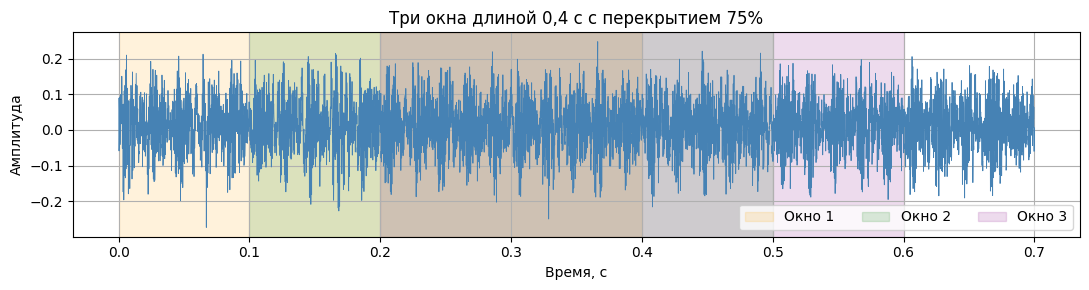

In [6]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(np.arange(7_000) / FS, signals["normal"][:7_000], lw=0.6, color="steelblue")
for i, color in enumerate(["orange", "green", "purple"]):
    start = i * 1_000 / FS
    ax.axvspan(start, start + 0.4, alpha=0.14, color=color,
               label=f"Окно {i + 1}")
ax.set(xlabel="Время, с", ylabel="Амплитуда", title="Три окна длиной 0,4 с с перекрытием 75%")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

## Признаки: 4000 отсчётов превращаются в 54 числа

Мы повторяем структуру исходного семинара: 14 временных, 13 спектральных,
10 полосовых, 5 признаков огибающей и 12 дополнительных признаков. RMS показывает
типичный уровень колебаний; огибающая помогает увидеть повторяющиеся удары;
энергия частотных полос показывает, где сосредоточены колебания.

![Synthetic signal mixture (синтетическая смесь сигналов) и смысл RMS](visualizations/03_synthetic_signal_mixture_and_RMS.png)

In [7]:
FEATURE_NAMES = [
    "mean", "median", "rms", "std", "variance", "maximum", "minimum", "range",
    "skewness", "kurtosis", "crest_ratio", "impulse_ratio", "shape_ratio", "time_energy",
    "spectral_max", "dominant_frequency", "spectral_centroid", "spectral_width",
    "spectral_entropy", "spectral_flatness", "mean_frequency", "median_frequency",
    "rolloff_85", "spectral_energy", "spectral_std", "spectral_skewness",
    "spectral_kurtosis",
    *[f"band_{low}_{low + 500}" for low in range(0, 5000, 500)],
    "envelope_spectral_max", "envelope_frequency", "envelope_spectral_energy",
    "envelope_entropy", "envelope_centroid", "envelope_mean", "envelope_std",
    "envelope_max", "envelope_kurtosis", "zero_crossing_rate", "high_mid_low_ratio",
    "envelope_energy_ratio", "absolute_crest_ratio", "fraction_below_q25",
    "small_to_large_amplitude", "small_to_large_energy", "q75_to_q25",
]


def extract_features(signal, fs=10_000):
    """54 time, spectrum and envelope features; one row per 0.4 s window."""
    x = np.asarray(signal, dtype=float)
    centered = x - x.mean()
    absolute = np.abs(centered)
    rms = np.sqrt(np.mean(centered ** 2))
    abs_mean = absolute.mean()
    eps = 1e-10

    time_features = [
        x.mean(), np.median(x), rms, centered.std(ddof=1),
        centered.var(ddof=1), x.max(), x.min(), np.ptp(x),
        skew(centered), kurtosis(centered), x.max() / (rms + eps),
        x.max() / (abs_mean + eps), rms / (abs_mean + eps),
        np.sum(centered ** 2),
    ]

    amplitude = np.abs(np.fft.rfft(centered))[:-1]  # exclude the Nyquist bin as in source
    frequency = np.fft.rfftfreq(len(x), d=1 / fs)[:-1]
    weights = amplitude / (amplitude.sum() + eps)
    cumulative = np.cumsum(weights)
    centroid = np.sum(frequency * weights)
    positive = weights[weights > 0]
    flatness = np.exp(np.mean(np.log(positive))) / (weights.mean() + eps)
    spectral_features = [
        amplitude.max(), frequency[np.argmax(amplitude)], centroid,
        np.sqrt(np.sum((frequency - centroid) ** 2 * weights)),
        -np.sum(positive * np.log(positive)), flatness, centroid,
        frequency[min(np.searchsorted(cumulative, 0.5), len(frequency) - 1)],
        frequency[min(np.searchsorted(cumulative, 0.85), len(frequency) - 1)],
        np.sum(amplitude ** 2), amplitude.std(ddof=1),
        skew(amplitude), kurtosis(amplitude),
    ]

    band_energy = np.array([
        np.sum(amplitude[(frequency >= low) & (frequency < low + 500)] ** 2)
        for low in range(0, 5000, 500)
    ])

    envelope = np.abs(hilbert(centered))
    env_amplitude = np.abs(np.fft.rfft(envelope - envelope.mean()))[:-1]
    env_weights = env_amplitude / (env_amplitude.sum() + eps)
    env_positive = env_weights[env_weights > 0]
    envelope_features = [
        env_amplitude.max(), frequency[np.argmax(env_amplitude)],
        np.sum(env_amplitude ** 2),
        -np.sum(env_positive * np.log(env_positive)),
        np.sum(frequency * env_weights),
    ]

    q25, _, q75 = np.quantile(absolute, [0.25, 0.5, 0.75])
    small = absolute[absolute < q25]
    large = absolute[absolute > q75]
    high_energy = band_energy[7:].sum()
    mid_energy = band_energy[3:7].sum()
    low_energy = band_energy[:3].sum()
    extra = [
        envelope.mean(), envelope.std(ddof=1), envelope.max(), kurtosis(envelope),
        np.count_nonzero(np.diff(np.sign(centered))) / len(x),
        (high_energy + mid_energy) / (low_energy + eps),
        np.sum(env_amplitude ** 2) / (np.sum(amplitude ** 2) + eps),
        absolute.max() / (rms + eps),
        len(small) / len(x),
        small.mean() / (large.mean() + eps),
        np.sum(small ** 2) / (np.sum(large ** 2) + eps),
        q75 / (q25 + eps),
    ]
    result = np.asarray(time_features + spectral_features + band_energy.tolist()
                        + envelope_features + extra, dtype=float)
    assert len(result) == len(FEATURE_NAMES) == 54
    return result

In [8]:
example = pd.DataFrame(
    [extract_features(segments[key][0], FS) for key in LABELS],
    index=[LABELS[key] for key in LABELS], columns=FEATURE_NAMES,
)
print("Признаков:", len(FEATURE_NAMES))
display(example[["rms", "dominant_frequency", "band_0_500", "zero_crossing_rate"]].round(3))
assert np.isfinite(example.to_numpy()).all()

Признаков: 54


,rms,dominant_frequency,band_0_500,zero_crossing_rate
Норма,0.074,1727.5,10117.964,0.324
Внутреннее кольцо,0.287,2400.0,8525.909,0.450
Внешнее кольцо,0.681,2870.0,10555.455,0.523
Ролик,0.136,2805.0,5505.009,0.506


## Synthetic signal mixtures (синтетические смеси сигналов): обучающая выборка

Для одного дефекта используем linear interpolation (линейную интерполяцию):
`normal + a × (defect − normal)`, где `a` — mixing coefficient (коэффициент смешивания).
При `a=0` получаем норму; при `a=1` — выбранный дефектный сигнал.
Для комбинаций используем linear superposition (линейное наложение) трёх
дефектных составляющих. Это не физическая модель износа.

**Разделение до генерации.** Для обучения берём окна с индексами 0–79,
для проверки — 84–116. Четыре пропущенных индекса создают зазор между
перекрывающимися окнами. Это уменьшает прямую утечку общих отсчётов.
Обе части всё ещё происходят из тех же четырёх записей, поэтому результат
проверки не показывает качество на новом подшипнике.

In [9]:
TRAIN_POOL = np.arange(0, 80)
TEST_POOL = np.arange(84, 117)
MIXING_COEFFICIENTS = np.array([0.05, 0.2, 0.4, 0.6, 0.8, 1.0])


def make_dataset(pool, n_normal, n_per_defect, n_combined, seed):
    rng = np.random.default_rng(seed)
    features, targets, kinds = [], [], []

    def add(signal, target, kind):
        features.append(extract_features(signal, FS))
        targets.append(target)
        kinds.append(kind)

    for idx in rng.choice(pool, size=n_normal, replace=True):
        add(segments["normal"][idx], [0, 0, 0], "норма")

    for target_col, defect_key in enumerate(["inner", "outer", "roller"]):
        for idx in rng.choice(pool, size=n_per_defect, replace=True):
            normal = segments["normal"][rng.choice(pool)]
            defect = segments[defect_key][idx]
            for mixing_coefficient in MIXING_COEFFICIENTS:
                mixture = normal + mixing_coefficient * (defect - normal)
                target = np.zeros(3)
                target[target_col] = 100 * mixing_coefficient
                add(mixture, target, LABELS[defect_key])

    for _ in range(n_combined):
        mixing_coefficients = rng.uniform(0, 1, 3)
        normal = segments["normal"][rng.choice(pool)]
        mixture = normal.copy()
        for mixing_coefficient, key in zip(mixing_coefficients, ["inner", "outer", "roller"]):
            defect = segments[key][rng.choice(pool)]
            mixture += mixing_coefficient * (defect - normal)
        add(mixture, 100 * mixing_coefficients, "комбинация")

    return np.vstack(features), np.vstack(targets), np.asarray(kinds)


X_train, y_train, kind_train = make_dataset(TRAIN_POOL, 25, 12, 400, seed=42)
X_test, y_test, kind_test = make_dataset(TEST_POOL, 12, 8, 160, seed=43)
print("Обучение: X", X_train.shape, "y", y_train.shape)
print("Проверка: X", X_test.shape, "y", y_test.shape)
print("Первые пять целевых векторов:", y_train[:5])
assert X_train.shape[1] == 54 and y_train.shape[1] == 3
assert np.isfinite(X_train).all() and np.isfinite(X_test).all()

Обучение: X (641, 54) y (641, 3)
Проверка: X (316, 54) y (316, 3)
Первые пять целевых векторов: [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## Нормализация без утечки

Средние и стандартные отклонения считаем **только на обучающей выборке**.
Проверочные данные преобразуем тем же `scaler`. Случайный лес не требует
нормализации для качества разбиений, но здесь она сохраняет учебную логику
исходного семинара и понадобится для некоторых других моделей.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Среднее первых трёх признаков после масштабирования:",
      np.round(X_train_scaled.mean(axis=0)[:3], 4))
print("Проверочная выборка преобразована теми же параметрами:", X_test_scaled.shape)

Среднее первых трёх признаков после масштабирования: [ 0.  0. -0.]
Проверочная выборка преобразована теми же параметрами: (316, 54)


## Три случайных леса

Один лес для каждого целевого столбца. Дерево задаёт последовательность вопросов
вида «RMS больше порога?», а лес усредняет ответы многих деревьев.
Для ролика используем больше деревьев, как в исходном материале; значения
глубины и числа деревьев здесь уменьшены ради времени занятия.

![Как случайный лес усредняет прогнозы деревьев](visualizations/04_случайный_лес.png)

In [11]:
models = {}
for j, key in enumerate(["inner", "outer", "roller"]):
    n_trees = 160 if key == "roller" else 120
    model = RandomForestRegressor(n_estimators=n_trees, max_depth=18,
                                  min_samples_leaf=2, random_state=42 + j,
                                  n_jobs=-1)
    model.fit(X_train_scaled, y_train[:, j])
    models[key] = model
    print(f"{LABELS[key]:20s}: {len(model.estimators_)} деревьев")

Внутреннее кольцо   : 120 деревьев


Внешнее кольцо      : 120 деревьев


Ролик               : 160 деревьев


## Оценка на отложенных окнах

MAE — средняя абсолютная разница между заданным mixing coefficient (коэффициентом смешивания)
и предсказанием, в пунктах шкалы 0–100. На графике диагональ означает
идеальное совпадение. Сравним также с простым прогнозом постоянного
среднего по обучающим данным.

,элемент,MAE модели,MAE константы
0,Внутреннее кольцо,2.31,29.98
1,Внешнее кольцо,1.48,29.61
2,Ролик,8.68,31.38


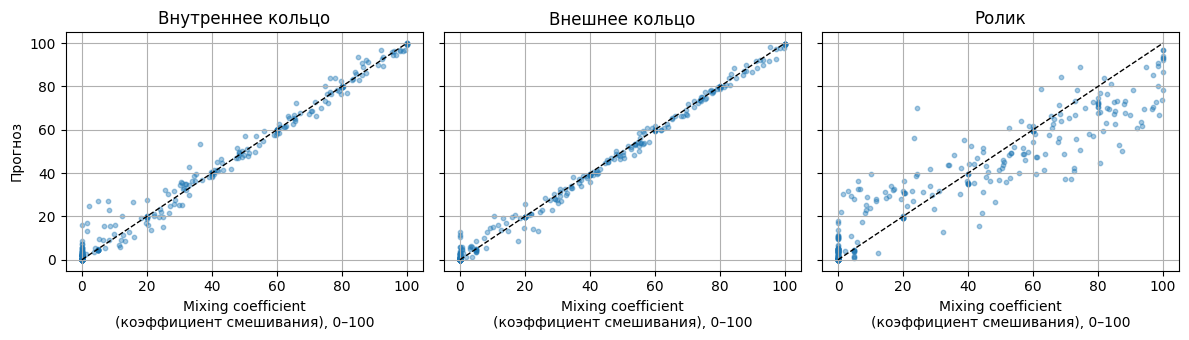

In [12]:
pred = np.column_stack([models[key].predict(X_test_scaled)
                        for key in ["inner", "outer", "roller"]])
baseline = np.tile(y_train.mean(axis=0), (len(y_test), 1))
scores = pd.DataFrame({
    "элемент": TARGET_NAMES,
    "MAE модели": [mean_absolute_error(y_test[:, j], pred[:, j]) for j in range(3)],
    "MAE константы": [mean_absolute_error(y_test[:, j], baseline[:, j]) for j in range(3)],
})
display(scores.round(2))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
for j, ax in enumerate(axes):
    ax.scatter(y_test[:, j], pred[:, j], s=10, alpha=0.4)
    ax.plot([0, 100], [0, 100], "k--", lw=1)
    ax.set_title(TARGET_NAMES[j])
    ax.set(xlabel="Mixing coefficient\n(коэффициент смешивания), 0–100", xlim=(-5, 105), ylim=(-5, 105))
axes[0].set_ylabel("Прогноз")
plt.tight_layout()
plt.show()

## Какие признаки использует модель?

Важность признака показывает, насколько часто он помогал уменьшать ошибку
в деревьях. Коррелирующие признаки могут делить важность между собой;
это не доказательство физической причины дефекта.

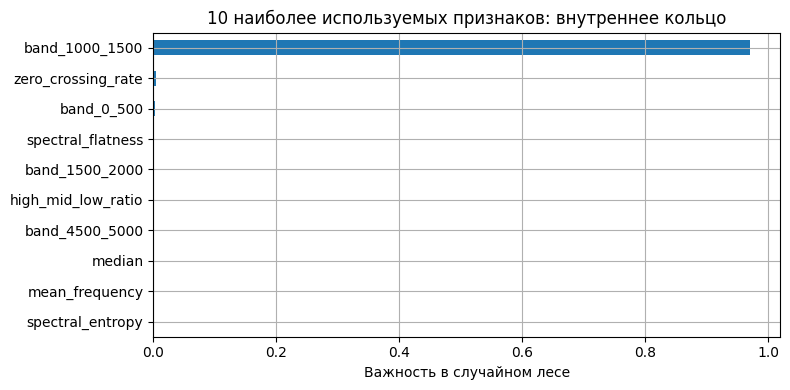

Три первых признака: ['band_1000_1500', 'zero_crossing_rate', 'band_0_500']


In [13]:
importance = pd.Series(models["inner"].feature_importances_,
                       index=FEATURE_NAMES).nlargest(10).sort_values()
ax = importance.plot.barh(figsize=(8, 4), title="10 наиболее используемых признаков: внутреннее кольцо")
ax.set_xlabel("Важность в случайном лесе")
plt.tight_layout()
plt.show()
print("Три первых признака:", importance.nlargest(3).index.tolist())

## Сохранение обученного комплекта

Нужны не только три леса, но и порядок признаков, параметры окон и обученный
масштабировщик. `joblib` читает pickle-формат: загружайте файл только из
доверенного источника.

In [14]:
bundle_path = OUT / "bearing_models_python.joblib"
joblib.dump({"models": models, "scaler": scaler, "feature_names": FEATURE_NAMES,
             "fs": FS, "segment_length": SEGMENT_LEN, "overlap": OVERLAP,
             "label_order": ["inner", "outer", "roller"]}, bundle_path)
bundle = joblib.load(bundle_path)
print("Сохранено:", bundle_path)
print("Моделей:", len(bundle["models"]), "| признаков:", len(bundle["feature_names"]))

Сохранено: output/bearing_models_python.joblib
Моделей: 3 | признаков: 54


## Вывод

Мы построили полный учебный конвейер акустической диагностики. Проверка на
отложенных фрагментах показывает, может ли модель восстановить mixing coefficients
(коэффициенты смешивания) в рамках этих четырёх записей. Для утверждений
о реальном износе нужны независимые подшипники, реальные метки состояния
и проверка в условиях другого стенда, скорости и шума.